In [ ]:
# -*- coding: utf-8 -*-
"""Trust_Code.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/17DSuF9ZrqL4DH1r_6VzRa8hyMI32UTFT
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Simulation parameters

ENGY=[50, 200] # Energy range in Watt-hrs
LONG=[0, 100] # Longitude 10 km
LAT= [0, 100] # Latitude 10 km
ALT=[5, 20] # Altitude 0.5 km ie 500 m

#Inital reputation score is based on below resources
clock_speed_range=[50, 257] # Clock speed is from 5 to 15 MHz
memory_range=[2, 17] #RAM size is 2 to 16 GB
power_consumption_range = [100, 120]

# Total number of trails
TRIALS = 10
ITERATIONS = 1

# Communication parameters
FREQUENCY = 2.4e9  # Frequency in Hz (2.4 GHz for WiFi)
BANDWIDTH = 20e6  # Bandwidth in Hz (20 MHz)
TRANSMISSION_POWER = 1  # Transmission power in Watts
NOISE_POWER = 1e-9  # Noise power in Watts (assumed)
SPEED_OF_LIGHT = 3e8  # Speed of light in meters per second
r=0.7 # Reputation weight
d=0.3 # Data Rate weight

def calculate_distance(uav1, uav2):
  """Calculates the Euclidean distance between two UAVs."""
  x1, y1, z1 = uav1.longitude, uav1.latitude, uav1.altitude
  x2, y2, z2 = uav2.longitude, uav2.latitude, uav2.altitude
  return np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)

def calculate_data_rate(distance):
  """Calculates the data rate between two UAVs given their distance."""
  path_loss = (SPEED_OF_LIGHT / (4 * np.pi * FREQUENCY * distance))**2
  snr = TRANSMISSION_POWER * path_loss / NOISE_POWER
  data_rate = BANDWIDTH * np.log2(1 + snr)
  return data_rate

# Function to update positions of UAVs
def update_uav_positions(uavs, long_range, lat_range, alt_range):
    for uav in uavs:
        uav.longitude = np.random.uniform(long_range[0], long_range[1])
        uav.latitude = np.random.uniform(lat_range[0], lat_range[1])
        uav.altitude = np.random.uniform(alt_range[0], alt_range[1])

# prompt: generate a class named uav, with the components of residual energy, memory, clock speed, logitude, latitude and altitude

class UAV:
  def __init__(self, residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption):
    self.residual_energy = residual_energy
    self.memory = memory
    self.clock_speed = clock_speed
    self.longitude = longitude
    self.latitude = latitude
    self.altitude = altitude
    self.avg_power_consumption = avg_power_consumption
    self.minimum_energy = residual_energy/10
    self.select_count = 0

class Task:
  def __init__(self, req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data):
    self.req_clock_speed = req_clock_speed
    self.req_memory = req_memory
    self.max_latency = max_latency
    self.data_volume = data_volume
    self.req_data_rate = data_volume / max_latency
    self.instructions_per_unit_data = instructions_per_unit_data
    self.total_instructions = instructions_per_unit_data*data_volume

energy_consumed_mean = np.zeros(TRIALS)

for iter in range(ITERATIONS):

    req_memory_range_array = [[1, 5], [6, 11], [12, 17]]

    task_dfs = []

    for mem_i, req_memory_range in enumerate(req_memory_range_array): # mem_i is the index of memory range (0, 1 or 2)
        # prompt: declare a variable num_uavs and create those many uavs with random parameters (i have LONG as the array of min and max ranges, LAT as the min and max ranges, and same the same thing for memory, clock_speed, and ALT for altitude)

        num_uavs = 20
        select_count = np.zeros(num_uavs)
        uavs = []
        for _ in range(num_uavs):
            residual_energy = np.random.uniform(ENGY[0], ENGY[1])
            memory = np.random.randint(memory_range[0], memory_range[1])
            clock_speed = np.random.randint(clock_speed_range[0], clock_speed_range[1])
            longitude = np.random.uniform(LONG[0], LONG[1])
            latitude = np.random.uniform(LAT[0], LAT[1])
            altitude = np.random.uniform(ALT[0], ALT[1])
            avg_power_consumption = np.random.uniform(power_consumption_range[0], power_consumption_range[1])
            uavs.append(UAV(residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption))

        # prompt: calculate initial reputation of uav as clock_speed*memory

        # Calculate initial reputation of UAVs
        uav_reputations = {}
        for i, uav in enumerate(uavs):
            uav_reputations[i] = uav.clock_speed * uav.memory

        # # Print initial reputations
        # print("Initial UAV Reputations:")
        # for uav_idx, reputation in uav_reputations.items():
        #     print(f"UAV {uav_idx}: {reputation}")

        energy_consumed_array = np.zeros(TRIALS)

        import pandas as pd
        # Create a list of dictionaries, where each dictionary represents a UAV
        task_data = []

        for trial in range(TRIALS):
            # prompt: calculate the data rate between every 2 uavs, i have only their positions. declare all the other variables required

            # Calculate data rates between all pairs of UAVs
            data_rates = np.zeros((num_uavs, num_uavs))
            for i in range(num_uavs):
                for j in range(i + 1, num_uavs):
                    distance = calculate_distance(uavs[i], uavs[j])
                    data_rate = calculate_data_rate(distance)
                    data_rates[i, j] = data_rate
                    data_rates[j, i] = data_rate  # Symmetric matrix

            # # Print the data rate matrix
            # print("Data Rate Matrix (in bits per second):\n", data_rates)

            # prompt: take a variable num_taks and generate the tasks with the random inputs

            # Ranges of task components
            req_clock_speed_range = [3, 5]
            req_memory_range = req_memory_range
            max_latency_range = [0.001, 0.01]
            data_volume_range = [10, 100]
            instructions_per_unit_data_range = [1e6, 2e6]

            num_tasks = 5
            tasks = []
            for _ in range(num_tasks):
                req_clock_speed = np.random.randint(req_clock_speed_range[0], req_clock_speed_range[1])
                req_memory = np.random.randint(req_memory_range[0], req_memory_range[1])
                max_latency = np.random.uniform(max_latency_range[0], max_latency_range[1])  # Example latency range
                data_volume = np.random.uniform(data_volume_range[0], data_volume_range[1])  # Example data volume range
                instructions_per_unit_data = np.random.randint(instructions_per_unit_data_range[0], instructions_per_unit_data_range[1])
                tasks.append(Task(req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data))

            # prompt: now asisgn each task to a uav randomly and divide the uavs into two sets, (task uav which is alloted tasks and remaining as service uav)

            # Assign tasks randomly to UAVs
            task_assignments = {}
            available_uavs = list(range(num_uavs))
            for task_idx in range(num_tasks):
                if available_uavs:
                    selected_uav = random.choice(available_uavs)
                    task_assignments[task_idx] = selected_uav
                    available_uavs.remove(selected_uav)

            # Divide UAVs into task UAVs and service UAVs
            task_uavs = list(task_assignments.values())
            service_uavs = [uav_idx for uav_idx in range(num_uavs) if uav_idx not in task_uavs]

            # print("Task Assignments:", task_assignments)
            # print("Task UAVs:", task_uavs)
            # print("Service UAVs:", service_uavs)

            # prompt: now check the eligibility of the service uavs for each task. to check the eligibility, we compare the memory and clock_speed requirements of the task with that of uav and also, we compare the req_data_rate of the task with the data rate between the uav and the task uav to which that task is associated with

            # Check eligibility of service UAVs for each task
            eligible_uavs = {}
            for task_idx, task_uav_idx in task_assignments.items():
                eligible_uavs[task_idx] = []
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    task = tasks[task_idx]
                    # Check resource requirements and data rate
                    if (service_uav.memory >= task.req_memory and
                        service_uav.clock_speed >= task.req_clock_speed and
                        data_rates[service_uav_idx, task_uav_idx] >= 2*task.req_data_rate and
                        service_uav.residual_energy >= service_uav.minimum_energy):
                        eligible_uavs[task_idx].append(service_uav_idx)

            # # Print eligible UAVs for each task
            # for task_idx, eligible in eligible_uavs.items():
            #     print(f"Eligible UAVs for Task {task_idx}: {eligible}")

            # prompt: get the reputation of only service uavs

            service_uav_reputations = {uav_idx: uav_reputations[uav_idx] for uav_idx in service_uavs}

            # print("Service UAV Reputations:")
            # for uav_idx, reputation in service_uav_reputations.items():
            #     print(f"UAV {uav_idx}: {reputation}")

            # prompt: for every task, calculate the trust between the uav associated with task and every other uav. trust = energy od the uav*(r*reputation + d*datarate between them)

            # Calculate trust values for each task
            trust_values = {}
            for task_idx, task_uav_idx in task_assignments.items():
                trust_values[task_idx] = {}
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    reputation = service_uav_reputations[service_uav_idx]
                    data_rate = data_rates[task_uav_idx, service_uav_idx]
                    trust = service_uav.residual_energy * (r * reputation + d * data_rate)
                    trust_values[task_idx][service_uav_idx] = trust

            # # Print trust values for each task
            # for task_idx, trust_dict in trust_values.items():
            #     print(f"Trust Values for Task {task_idx}:")
            #     for service_uav_idx, trust in trust_dict.items():
            #         print(f"  Service UAV {service_uav_idx}: {trust:.2f}")

            # prompt: calculate the transmission delay, propagation delay and energy required to transmit a task from task uav to every other service uav

            # Calculate transmission, propagation delays, and energy consumption for each task and service UAV
            for task_idx, task_uav_idx in task_assignments.items():
                task = tasks[task_idx]
                task_uav = uavs[task_uav_idx]
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    distance = calculate_distance(task_uav, service_uav)
                    data_rate = data_rates[task_uav_idx, service_uav_idx]

                    # Transmission Delay
                    transmission_delay = task.data_volume*1024*1024 / data_rate

                    # Propagation Delay
                    propagation_delay = distance / SPEED_OF_LIGHT

                    # Energy Consumption (assuming simple linear model)
                    energy_consumption = TRANSMISSION_POWER * transmission_delay

            # prompt: for each task, select the service uav wiith minimum (total delay + energy consumption)

            # Calculate total cost (delay + energy) and select service UAV with minimum cost for each task
            selected_service_uavs = {}

            for task_idx, task_uav_idx in task_assignments.items():
                task = tasks[task_idx]
                task_uav = uavs[task_uav_idx]
                min_cost = float('inf')
                selected_uav = None

                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    distance = calculate_distance(task_uav, service_uav)
                    data_rate = data_rates[task_uav_idx, service_uav_idx]

                    transmission_delay = task.data_volume * 1024 * 1024 / data_rate
                    propagation_delay = distance / SPEED_OF_LIGHT
                    energy_consumption = TRANSMISSION_POWER * transmission_delay

                    total_cost = transmission_delay + propagation_delay + energy_consumption

                    if total_cost < min_cost:
                        min_cost = total_cost
                        selected_uav = service_uav_idx

                if selected_uav is not None:
                    selected_service_uavs[task_idx] = selected_uav
                    service_uavs.remove(selected_uav)  # Remove selected UAV to avoid repetition


            # # prompt: for each task, select the service uav with maximum trust. note that once the service uav is selected, then do not consider it for the allocating another task

            # # Select service UAV with maximum trust for each task (without repetition)
            # selected_service_uavs = {}
            # used_service_uavs = set()

            # for task_idx, trust_dict in trust_values.items():
            #     # Sort eligible UAVs by trust in descending order
            #     sorted_uavs = sorted(trust_dict, key=trust_dict.get, reverse=True)

            #     for service_uav_idx in sorted_uavs:
            #         if service_uav_idx not in used_service_uavs:
            #             selected_service_uavs[task_idx] = service_uav_idx
            #             used_service_uavs.add(service_uav_idx)
            #             uavs[service_uav_idx].select_count += 1 # increment select count if uav is selected
            #             break

            # # # Print the selected service UAV for each task
            # # print("\nSelected Service UAVs:")
            # # for task_idx, service_uav_idx in selected_service_uavs.items():
            # #     print(f"Task {task_idx}: Service UAV {service_uav_idx}")

            for task_idx, service_uav_idx in selected_service_uavs.items():
                select_count[service_uav_idx]+=1

                # print(select_count)

            # prompt: calculate discounting factor for each uav where discounting_factor = (total_reputation/reputation_of_uav), then scale it down to 0 to 4 and then apply sigmoid to get the range between 0 to 1

            # Calculate total reputation
            total_reputation = sum(uav_reputations.values())

            # Calculate discounting factors
            discounting_factors = {}
            for uav_idx, reputation in uav_reputations.items():
                discounting_factors[uav_idx] = total_reputation / reputation

            # Scale down to 0 to 4 range
            scaled_factors = {}
            max_factor = max(discounting_factors.values())
            for uav_idx, factor in discounting_factors.items():
                scaled_factors[uav_idx] = (factor / max_factor) * 4

            # Apply sigmoid function
            sigmoid_factors = {}
            for uav_idx, factor in scaled_factors.items():
                sigmoid_factors[uav_idx] = 1 / (1 + np.exp(-factor))

            # # Print sigmoid discounting factors
            # print("\nSigmoid Discounting Factors:")
            # for uav_idx, factor in sigmoid_factors.items():
            #     print(f"UAV {uav_idx}: {factor:.4f}")

            # prompt: calculate the award to be given by the task uav to service uav for completing a task. award = (1-discounting factor of service uav)/(1-discounting factor of service uav*discounting factor of task uav)

            # Calculate awards for selected service UAVs
            awards = {}
            for task_idx, service_uav_idx in selected_service_uavs.items():
                task_uav_idx = task_assignments[task_idx]
                discounting_factor_service = sigmoid_factors[service_uav_idx]
                discounting_factor_task = sigmoid_factors[task_uav_idx]
                award = (1 - discounting_factor_service) / (1 - discounting_factor_service * discounting_factor_task)
                awards[task_idx] = {
                    'service_uav': service_uav_idx,
                    'award': award
                }

            # # Print the awards
            # print("\nAwards for Service UAVs:")
            # for task_idx, award_info in awards.items():
            #     print(f"Task {task_idx}: Service UAV {award_info['service_uav']} receives an award of {award_info['award']:.4f}")

            # prompt: now transfer the score, for transfering the score, the reputation of the task uav which gave the task should reduce by this fraction of award, i.e.  reputation of the task uav =  reputation of the task uav(1-award) and reputation of the service uav =  reputation of the service uav+  reputation of the task uav*award

            # Transfer scores based on awards
            for task_idx, award_info in awards.items():
                service_uav_idx = award_info['service_uav']
                task_uav_idx = task_assignments[task_idx]
                award = award_info['award']

                # Update reputations
                temp = uav_reputations[task_uav_idx]
                uav_reputations[task_uav_idx] *= (1 - award)
                uav_reputations[service_uav_idx] += temp * award

            # # Print updated reputations
            # print("\nUpdated UAV Reputations:")
            # for uav_idx, reputation in uav_reputations.items():
            #     print(f"UAV {uav_idx}: {reputation:.2f}")

            # Update UAV positions after an iteration of the task
            update_uav_positions(uavs, LONG, LAT, ALT)

            # # Print updated positions for verification
            # for i, uav in enumerate(uavs):
            #     print(f"UAV {i+1}: Longitude = {uav.longitude}, Latitude = {uav.latitude}, Altitude = {uav.altitude}")

            # prompt: recalculate the residual energy of the service uav by reducing it by avg power * time of execution. and also reduct the energy of task uav the enrgy required to transmit the task, you have the task size and all the other parameters, it is upto you if any other variable that are needed to be declared.

            # Calculate execution times for tasks
            total_energy_consumed = 0
            execution_times = {}
            exec_times_arr = []
            transmission_times = {}
            service_energy_arr = []
            task_energy_arr = []

            trans_times_arr = []
            for task_idx, service_uav_idx in selected_service_uavs.items():
                task = tasks[task_idx]
                service_uav = uavs[service_uav_idx]
                execution_time = task.total_instructions / (service_uav.clock_speed*1e6)
                execution_time = execution_time / 3600
                execution_times[task_idx] = execution_time
                exec_times_arr.append(execution_time)

                # Reduce service UAV's residual energy
                energy_consumed_service = service_uav.avg_power_consumption * execution_time
                total_energy_consumed += energy_consumed_service
                service_energy_arr.append(energy_consumed_service)

                # Reduce task UAV's residual energy
                uavs[service_uav_idx].residual_energy -= energy_consumed_service

                # Calculate energy consumed by task UAV for transmission (simplified model)
                task_uav_idx = task_assignments[task_idx]
                distance = calculate_distance(uavs[task_uav_idx], uavs[service_uav_idx])
                transmission_time = (task.data_volume*1024*1024) / calculate_data_rate(distance)
                transmission_time = transmission_time / 3600
                transmission_times[task_idx] = transmission_time
                trans_times_arr.append(transmission_time)

                energy_consumed_task = TRANSMISSION_POWER * transmission_time
                total_energy_consumed += energy_consumed_task
                task_energy_arr.append(energy_consumed_task)
                uavs[task_uav_idx].residual_energy -= energy_consumed_task

                # # Print execution times
                # print("\nTask Execution Times:")
                # for task_idx, time in execution_times.items():
                #     print(f"Task {task_idx}: {time:.4f} hours")

                # # Print updated residual energies
                # print("\nUpdated Residual Energies:")
                # for i, uav in enumerate(uavs):
                #     print(f"UAV {i}: {uav.residual_energy:.2f} Watt-hrs")

            # print("Total energy consumed: ", total_energy_consumed)
            energy_consumed_array[trial] = total_energy_consumed

            # prompt: create a dataframe named uav for all the uavs and the components of uav class as the columns
            for i in range (len(trans_times_arr)):
                task_data.append({
                    # 'Task ID': (i+1)*(trial+1),
                    'Task ID': i,
                    'Trial': trial,
                    'Task Energy': task_energy_arr[i],
                    'Service Energy': service_energy_arr[i]
                })

        # print(energy_consumed_array)
        energy_consumed_mean += energy_consumed_array

        # Create the DataFrame from the list of dictionaries
        task_df = pd.DataFrame(task_data)
        task_df.to_csv(f'task_data_{mem_i}_dpto.csv', index=False)

        # Display the DataFrame
        # print(task_df)
        task_dfs.append(task_df)
    print(len(task_dfs))

3


In [ ]:
# prompt: read the task_data_0_dpto.csv to get a df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

df = pd.read_csv('task_data_0_dpto.csv')

df.head()

,Task ID,Trial,Task Energy,Service Energy
0,0,0,0.000154,0.050914
1,1,0,0.000188,0.032342
2,2,0,0.000196,0.027716
3,3,0,0.000047,0.008525
4,4,0,0.000187,0.025747


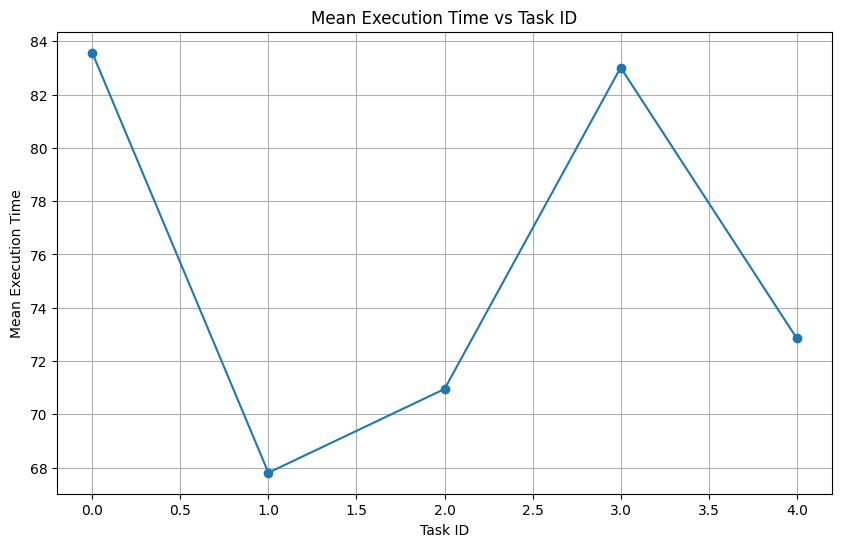

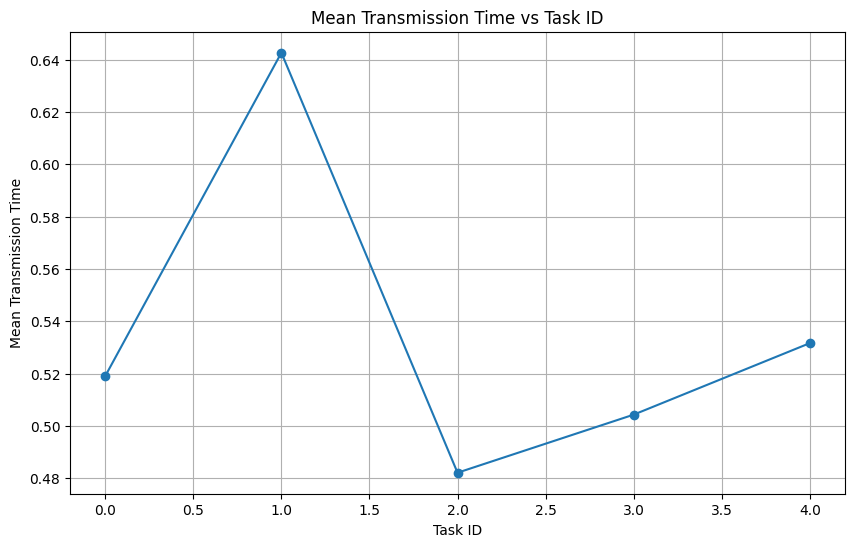

In [ ]:
# prompt: find the mean value of transmission and execution times for each task over the 100 trials and plot it (execution times vs task id, transmission times vs task id)

import matplotlib.pyplot as plt
# Calculate mean transmission and execution times
mean_transmission_times = df.groupby('Task ID')['Task Energy'].mean()*3600
mean_execution_times = df.groupby('Task ID')['Service Energy'].mean()*3600

# Plot execution times vs task id
plt.figure(figsize=(10, 6))
plt.plot(mean_execution_times.index, mean_execution_times.values, marker='o')
plt.xlabel('Task ID')
plt.ylabel('Mean Execution Time')
plt.title('Mean Execution Time vs Task ID')
plt.grid(True)
plt.show()

# Plot transmission times vs task id
plt.figure(figsize=(10, 6))
plt.plot(mean_transmission_times.index, mean_transmission_times.values, marker='o')
plt.xlabel('Task ID')
plt.ylabel('Mean Transmission Time')
plt.title('Mean Transmission Time vs Task ID')
plt.grid(True)
plt.show()

In [ ]:
print(np.mean(mean_execution_times.values))
print(np.mean(mean_transmission_times.values))

0.6795165065212587
0.5477106289138106


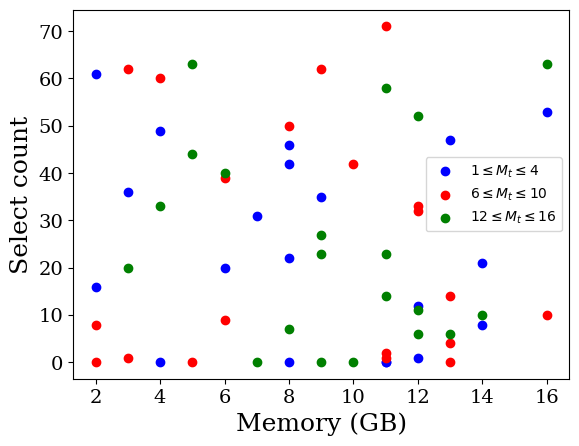

In [ ]:
# prompt: plot a scatter plot of residual energy vs select count for all the 3 dataframes, uav_dfs[0], [1], [2]. each with different color

import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman'] + rcParams['font.serif']
plt.xlabel('Memory (GB)', fontsize=18)
plt.ylabel('Select count', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Assuming 'Residual Energy' and 'Select Count' are columns in your dataframes
plt.scatter(uav_dfs[0]['Memory'], uav_dfs[0]['Select Count'], color='blue', label='$1 \leq M_t \leq 4$')
plt.scatter(uav_dfs[1]['Memory'], uav_dfs[1]['Select Count'], color='red', label='$6 \leq M_t \leq 10$')
plt.scatter(uav_dfs[2]['Memory'], uav_dfs[2]['Select Count'], color='green', label='$12 \leq M_t \leq 16$')

plt.legend()
plt.show()

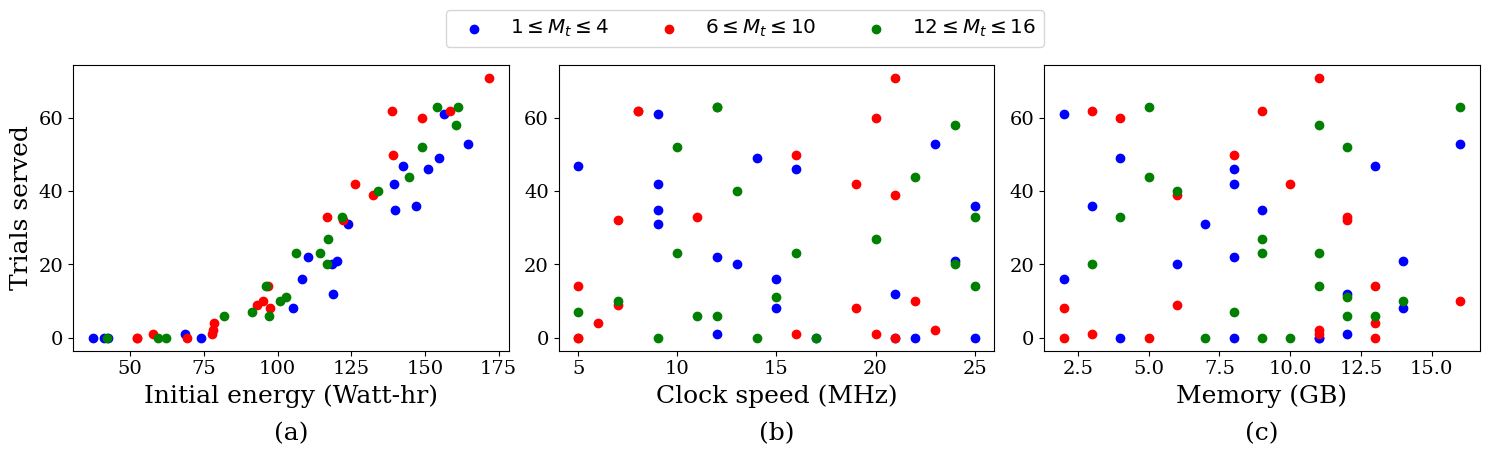

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman'] + rcParams['font.serif']

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# Plot 1: Residual Energy vs Select Count
axes[0].scatter(uav_dfs[0]['Residual Energy'], uav_dfs[0]['Select Count'], color='blue')
axes[0].scatter(uav_dfs[1]['Residual Energy'], uav_dfs[1]['Select Count'], color='red')
axes[0].scatter(uav_dfs[2]['Residual Energy'], uav_dfs[2]['Select Count'], color='green')
axes[0].set_xlabel('Initial energy (Watt-hr)', fontsize=18)
axes[0].set_ylabel('Trials served', fontsize=18)
axes[0].text(0.5, -0.25, '(a)', transform=axes[0].transAxes, fontsize=18, va='top', ha='center')

# Plot 2: Clock Speed vs Select Count
axes[1].scatter(uav_dfs[0]['Clock Speed'], uav_dfs[0]['Select Count'], color='blue', label='$1 \leq M_t \leq 4$')
axes[1].scatter(uav_dfs[1]['Clock Speed'], uav_dfs[1]['Select Count'], color='red', label='$6 \leq M_t \leq 10$')
axes[1].scatter(uav_dfs[2]['Clock Speed'], uav_dfs[2]['Select Count'], color='green', label='$12 \leq M_t \leq 16$')
axes[1].set_xlabel('Clock speed (MHz)', fontsize=18)
# axes[1].set_ylabel('Select count', fontsize=18)
axes[1].text(0.5, -0.25, '(b)', transform=axes[1].transAxes, fontsize=18, va='top', ha='center')

# Plot 3: Memory vs Select Count
axes[2].scatter(uav_dfs[0]['Memory'], uav_dfs[0]['Select Count'], color='blue')
axes[2].scatter(uav_dfs[1]['Memory'], uav_dfs[1]['Select Count'], color='red')
axes[2].scatter(uav_dfs[2]['Memory'], uav_dfs[2]['Select Count'], color='green')
axes[2].set_xlabel('Memory (GB)', fontsize=18)
# axes[2].set_ylabel('Select count', fontsize=18)
axes[2].text(0.5, -0.25, '(c)', transform=axes[2].transAxes, fontsize=18, va='top', ha='center')

# Set xticks and yticks size to 14
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# Single legend for all plots
handles, labels = axes[1].get_legend_handles_labels()  # Get handles and labels from one of the plots
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize='x-large')  # Place legend above the plots

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.9])  # Adjust layout to accommodate the legend

plt.savefig('trials_served_vs_resource.pdf', format='pdf', bbox_inches='tight')
plt.show()
